In [5]:
install.packages("geoR")

Installation du package dans 'C:/Users/reych/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)



package 'geoR' successfully unpacked and MD5 sums checked

Les packages binaires téléchargés sont dans
	C:\Users\reych\AppData\Local\Temp\RtmpOg4ZJe\downloaded_packages


In [ ]:
library(geoR)
data(wolfcamp)

--------------------------------------------------------------
 Analysis of Geostatistical Data
 For an Introduction to geoR go to http://www.leg.ufpr.br/geoR
 geoR version 1.9-6 (built on 2025-08-29) is now loaded
--------------------------------------------------------------




We got wolfcamp data. In a first time, we will analyse the data in order to understand their repartition.

Number of data points: 85 

Coordinates summary
      Coord.X   Coord.Y
min -233.7217 -145.7884
max  181.5314  136.4061

Distance summary
        min         max 
  0.3669819 436.2067085 

Data summary
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
 312.1095  471.8218  547.7156  610.2845  774.1778 1088.4209 

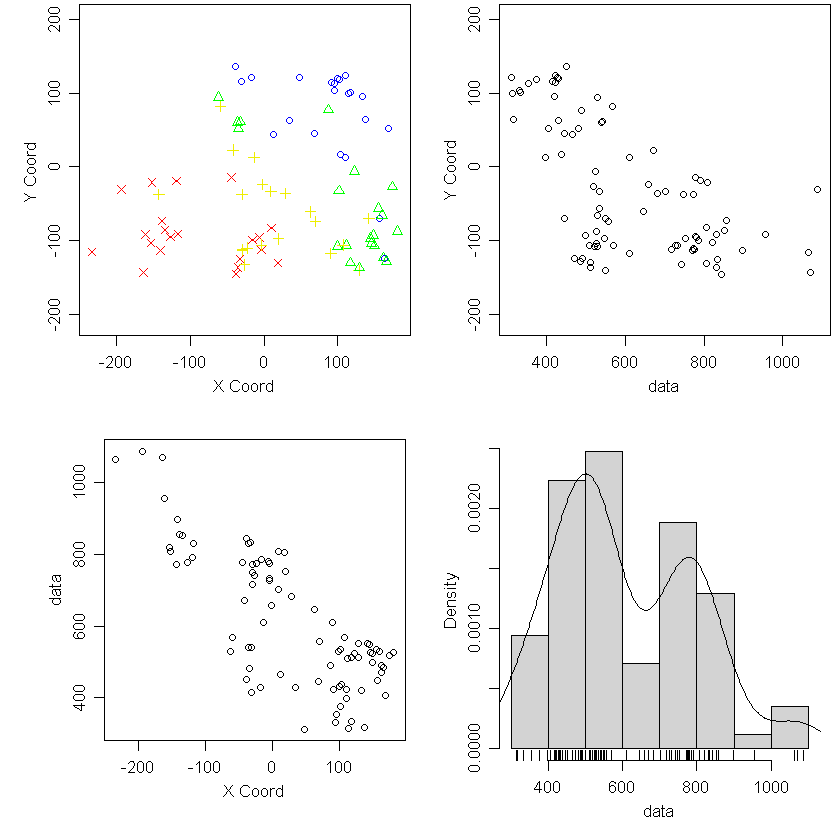

In [ ]:
summary(wolfcamp)

plot(wolfcamp)

Then, we create a csv file so as to stock the data.

In [ ]:
wolfcamp_df <- data.frame(
  x = wolfcamp$coords[,1], 
  y = wolfcamp$coords[,2], 
  niveau_eau = wolfcamp$data
)

write.csv(wolfcamp_df, file = "wolfcamp_data.csv", row.names = FALSE)

head(wolfcamp_df)

,x,y,niveau_eau
,<dbl>,<dbl>,<dbl>
1,68.851186,44.45399,446.2190
2,-44.090428,-14.82616,778.1401
3,-1.871464,-24.30719,657.7464
4,-29.962712,-37.89631,748.2703
5,155.243957,-57.00122,535.2190
6,174.711819,-27.48198,518.7601


Link to discover the first discussion : https://share.gemini.google/mQVoQ6oey1LJ

In [10]:
install.packages("sf")

Installation du package dans 'C:/Users/reych/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)

installation des dépendances 'proxy', 'e1071', 'wk', 'classInt', 's2', 'units'




package 'proxy' successfully unpacked and MD5 sums checked
package 'e1071' successfully unpacked and MD5 sums checked
package 'wk' successfully unpacked and MD5 sums checked
package 'classInt' successfully unpacked and MD5 sums checked
package 's2' successfully unpacked and MD5 sums checked
package 'units' successfully unpacked and MD5 sums checked
package 'sf' successfully unpacked and MD5 sums checked

Les packages binaires téléchargés sont dans
	C:\Users\reych\AppData\Local\Temp\RtmpOg4ZJe\downloaded_packages


In [11]:
install.packages("gstat")

Installation du package dans 'C:/Users/reych/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)

installation des dépendances 'xts', 'intervals', 'abind', 'sftime', 'spacetime', 'stars', 'FNN'




package 'xts' successfully unpacked and MD5 sums checked
package 'intervals' successfully unpacked and MD5 sums checked
package 'abind' successfully unpacked and MD5 sums checked
package 'sftime' successfully unpacked and MD5 sums checked
package 'spacetime' successfully unpacked and MD5 sums checked
package 'stars' successfully unpacked and MD5 sums checked
package 'FNN' successfully unpacked and MD5 sums checked
package 'gstat' successfully unpacked and MD5 sums checked

Les packages binaires téléchargés sont dans
	C:\Users\reych\AppData\Local\Temp\RtmpOg4ZJe\downloaded_packages


In [22]:
install.packages("MBA")

Installation du package dans 'C:/Users/reych/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)



package 'MBA' successfully unpacked and MD5 sums checked

Les packages binaires téléchargés sont dans
	C:\Users\reych\AppData\Local\Temp\RtmpOg4ZJe\downloaded_packages


Now, we choose the parameter p which allows to have the best predictions with the inverse distance weighted estimator.

   Power       MSE
1   0.50 23042.854
2   0.75 17505.897
3   1.00 13097.774
4   1.25  9953.462
5   1.50  7852.567
6   1.75  6494.728
7   2.00  5626.494
8   2.25  5071.685
9   2.50  4717.988
10  2.75  4495.680
11  3.00  4360.707
12  3.25  4284.191
13  3.50  4246.664
14  3.75  4234.845
15  4.00  4239.666
16  4.25  4254.957
17  4.50  4276.545
18  4.75  4301.632
19  5.00  4328.362
20  5.25  4355.524
21  5.50  4382.351
22  5.75  4408.372
23  6.00  4433.314
24  6.25  4457.042
25  6.50  4479.502
26  6.75  4500.698
27  7.00  4520.665
28  7.25  4539.459
29  7.50  4557.144
30  7.75  4573.787
31  8.00  4589.459
32  8.25  4604.223
33  8.50  4618.142
34  8.75  4631.273
35  9.00  4643.671
36  9.25  4655.385
37  9.50  4666.459
38  9.75  4676.935
39 10.00  4686.852

The optimal power parameter (p) is: 3.75 


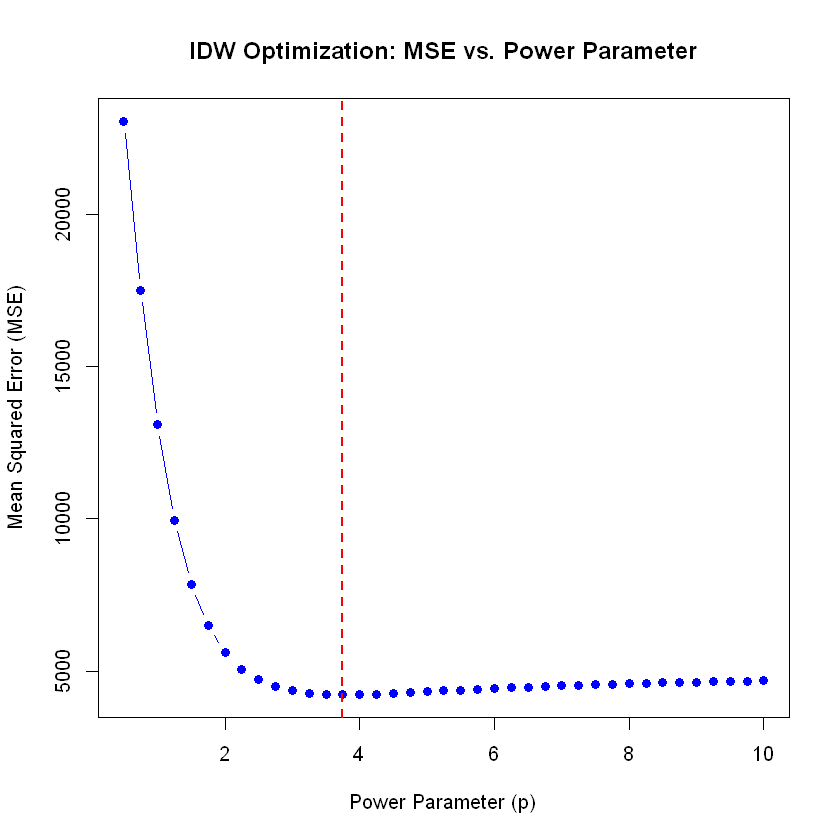

In [21]:
# 1. Load required libraries
library(sf)
library(gstat)

# 1. Read the CSV file into an R data.frame
wolfcamp <- read.csv("wolfcamp_data.csv")

# 2. Convert the loaded data.frame into a spatial (sf) object

wolfcamp_sf <- st_as_sf(wolfcamp, coords = c("x", "y"))

# 3. Define a sequence of power parameters (p) to test
p_values <- seq(0.5, 10.0, by = 0.25)

# Initialize an empty vector to store the MSE for each p
mse_results <- numeric(length(p_values))

# 4. Outer Loop: Iterate over each possible parameter p
for (i in seq_along(p_values)) {
  
  current_p <- p_values[i]
  squared_errors <- numeric(nrow(wolfcamp_sf))
  
  # 5. Inner Loop: Leave-One-Out Cross-Validation
  for (j in 1:nrow(wolfcamp_sf)) {
    
    # STRICT SEPARATION: Remove test point 'j' from training data
    train_data <- wolfcamp_sf[-j, ]
    test_data  <- wolfcamp_sf[j, ]
    
    # Fit IDW model on training data and predict on the test point
    # 'idp' is the gstat argument for the power parameter
    idw_fit <- idw(
      formula = niveau_eau ~ 1,
      locations = train_data,
      newdata = test_data,
      idp = current_p,
      debug.level = 0 # Suppress console output for speed
    )
    
    # Extract prediction and calculate squared error
    predicted_val <- idw_fit$var1.pred
    actual_val <- test_data$niveau_eau
    
    squared_errors[j] <- (predicted_val - actual_val)^2
  }
  
  # 6. Calculate the Mean Squared Error for the current p
  mse_results[i] <- mean(squared_errors)
}

# 7. Identify the optimal p
results_df <- data.frame(Power = p_values, MSE = mse_results)
optimal_p <- results_df$Power[which.min(results_df$MSE)]

print(results_df)
cat("\nThe optimal power parameter (p) is:", optimal_p, "\n")
# Plot the evolution of MSE vs. p
plot(results_df$Power, results_df$MSE, type = "b", pch = 19, col = "blue",
     xlab = "Power Parameter (p)", ylab = "Mean Squared Error (MSE)",
     main = "IDW Optimization: MSE vs. Power Parameter")

# Add a vertical red dashed line to highlight the optimal p
abline(v = optimal_p, col = "red", lty = 2, lwd = 2)

In [24]:
library(sf)
library(gstat)
library(MBA)

# ---------------------------------------------------------
# PART 1: Define the 20x20 Grid
# ---------------------------------------------------------
# Create a sequence of 20 evenly spaced X and Y coordinates
x_seq <- seq(min(wolfcamp$x), max(wolfcamp$x), length.out = 20)
y_seq <- seq(min(wolfcamp$y), max(wolfcamp$y), length.out = 20)

# Combine them into a grid of 400 points
pred_grid <- expand.grid(x = x_seq, y = y_seq)
grid_sf <- st_as_sf(pred_grid, coords = c("x", "y"))

# ---------------------------------------------------------
# PART 2: Interpolate on the Grid
# ---------------------------------------------------------
# A. IDW Interpolation on the grid (using your optimal_p from earlier)
idw_grid_result <- idw(
  formula = niveau_eau ~ 1, 
  locations = wolfcamp_sf, 
  newdata = grid_sf, 
  idp = 3.75
)

# B. MBA Interpolation on the grid
# mba.surf takes an [x, y, z] matrix and grid dimensions
xyz_data <- wolfcamp[, c("x", "y", "niveau_eau")]
mba_grid_result <- mba.surf(xyz_data, no.X = 20, no.Y = 20, extend = TRUE)

# ---------------------------------------------------------
# PART 3: Calculate a "Proper Score" (LOOCV RMSE)
# ---------------------------------------------------------

# A. Score IDW (using gstat's built-in krige.cv)
idw_cv <- krige.cv(niveau_eau ~ 1, wolfcamp_sf, set = list(idp = optimal_p), debug.level = 0)
idw_rmse <- sqrt(mean(idw_cv$residual^2))

# B. Score MBA (Manual LOOCV using mba.points)
mba_residuals <- numeric(nrow(wolfcamp))

for (i in 1:nrow(wolfcamp)) {
  # Separate train and test
  train_xyz <- xyz_data[-i, ]
  test_xy <- xyz_data[i, c("x", "y")]
  
  # Predict the left-out point using mba.points
  mba_pred <- mba.points(train_xyz, test_xy)$xyz.est
  
  # Calculate residual (Actual - Predicted)
  actual_val <- xyz_data$niveau_eau[i]
  predicted_val <- mba_pred[1, "z"]
  
  mba_residuals[i] <- actual_val - predicted_val
}

mba_rmse <- sqrt(mean(mba_residuals^2))

# ---------------------------------------------------------
# PART 4: Compare
# ---------------------------------------------------------
cat("Proper Score Comparison (Root Mean Squared Error):\n")
cat("IDW RMSE: ", idw_rmse, "\n")
cat("MBA RMSE: ", mba_rmse, "\n\n")

if(idw_rmse < mba_rmse) {
  cat("Conclusion: IDW is the more accurate method for this dataset.\n")
} else {
  cat("Conclusion: Multilevel B-Splines (MBA) is the more accurate method for this dataset.\n")
}

[inverse distance weighted interpolation]


Warning message in mba.points(train_xyz, test_xy):
"domain extended in the +y direction(s)"
Warning message in mba.points(train_xyz, test_xy):
"domain extended in the +x direction(s)"
Warning message in mba.points(train_xyz, test_xy):
"domain extended in the -y direction(s)"
Warning message in mba.points(train_xyz, test_xy):
"domain extended in the -x direction(s)"


Proper Score Comparison (Root Mean Squared Error):
IDW RMSE:  65.07569 
MBA RMSE:  59.87362 

Conclusion: Multilevel B-Splines (MBA) is the more accurate method for this dataset.
